<a href="https://colab.research.google.com/github/nithyasg05/A01-data-wrangling/blob/main/DS_3001_A01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Nithya Gopal

**Date:** 9/5/26

In [3]:
# Your Phase 1 solution to the problem goes here.

!git clone https://github.com/nithyasg05/A01-data-wrangling.git

Cloning into 'A01-data-wrangling'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 9 (from 1)
Receiving objects: 100% (12/12), 3.43 MiB | 12.90 MiB/s, done.


In [4]:
!ls

A01-data-wrangling  sample_data


In [5]:
!cd A01-data-wrangling

!ls

A01-data-wrangling  sample_data


In [6]:
!cd A01-data-wrangling/data

**Question 1 - Part 1**

In [7]:
import pandas as pd

df_airbnb = pd.read_csv('/content/A01-data-wrangling/data/airbnb_hw.csv')
display(df_airbnb.head())

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0


Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 



<Axes: >

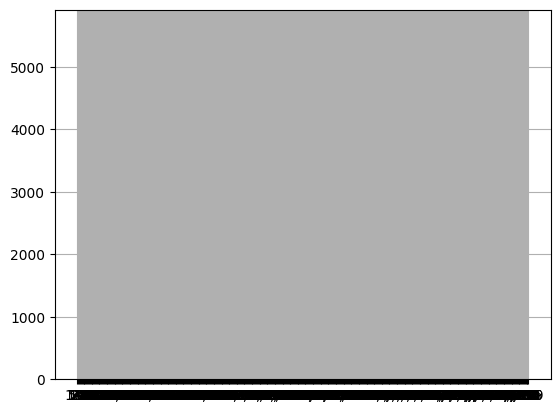

In [8]:
var = 'Price'
print('Before coercion:\n', df_airbnb[var].describe(), '\n')
df_airbnb[var].hist(bins=50)

After cleaning and coercion (commas removed only):
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missing values after comma removal:
 0 



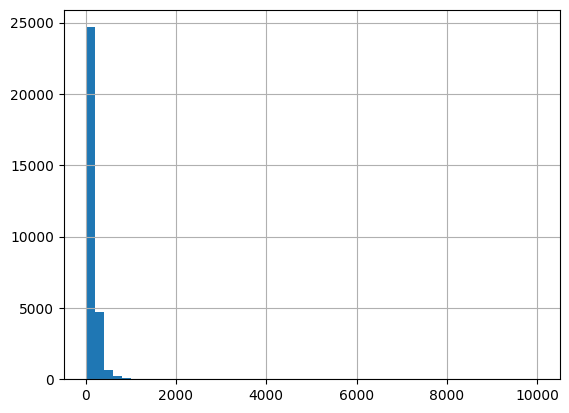

In [35]:
import pandas as pd

df_airbnb = pd.read_csv('/content/A01-data-wrangling/data/airbnb_hw.csv')

# To clean the 'Price' column, I first chose to remove commas because when a price goes above 999 and into the thousands, it introduces a comma and raises an error.
# Then, I converted the column to a numeric type and turned any values that can't be converted into missing values (NaN)
# Before cleaning, there were 181 missing values, but now there are 0.
df_airbnb['Price'] = df_airbnb['Price'].astype(str).str.replace(',', '', regex=False)
df_airbnb['Price'] = pd.to_numeric(df_airbnb['Price'], errors='coerce')
df_airbnb['Price_nan'] = df_airbnb['Price'].isnull()

print('After cleaning and coercion (commas removed only):\n', df_airbnb['Price'].describe(), '\n')
df_airbnb['Price'].hist(bins=50)
print('Total missing values after comma removal:\n', sum(df_airbnb['Price_nan']), '\n')

**Question 1 - Part 2**

In [10]:
import pandas as pd

df_police = pd.read_csv('/content/A01-data-wrangling/data/mn_police_use_of_force.csv')
display(df_police.head())

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [11]:
df_police['subject_injury'].value_counts(dropna=False)

,count
subject_injury,
NaN,9848
Yes,1631
No,1446


In [28]:
# Cleaning the 'subject_injury' column, so it's either 'Yes' (injured) or 'No' (not injured).
# Any entries that are unclear or missing are assumed to mean 'No'
df_police['subject_injury_cleaned'] = df_police['subject_injury'].map({'Yes': 'Yes', 'No': 'No'}).fillna('No')

proportion_missing = df_police['subject_injury'].isnull().sum() / len(df_police)
print(f"Proportion of missing values in 'subject_injury': {proportion_missing:.4f}\n")

print('Cleaned values and counts for subject_injury:\n', df_police['subject_injury_cleaned'].value_counts())

# Originally, 76.19% of values were missing (NaN) and these missing values were imputed to 'No', resulting in a cleaned variable with 11294 'No' entries and 1631 'Yes' entries
# I believe that a proportion of 76.19% missing values is a concern - this could introduce bias if the missingness is not random and means we lack information for a large majority of incidents, leading to misrepresentation of the data.

print('\nCross-tabulation of cleaned subject_injury with force_type:\n')
display(pd.crosstab(df_police['subject_injury_cleaned'], df_police['force_type']))

Proportion of missing values in 'subject_injury': 0.7619

Cleaned values and counts for subject_injury:
 subject_injury_cleaned
No     11294
Yes     1631
Name: count, dtype: int64

Cross-tabulation of cleaned subject_injury with force_type:



force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury_cleaned,,,,,,,,,,,
No,2,8144,1552,2,60,108,87,1,170,33,1135
Yes,2,1286,41,0,44,40,0,2,0,44,172


The cross tabulation shows that Bodily Force has the highest number of missing subject_injury entrie and Firearm shows 100% missing values for subject_injury.

This suggests that the missingness is not random and is highly associated with the type of force used. Specifically, for 'Firearm' incidents, there's no reported injury status, which could indicate a lack of data collection.

**Question 2 - Part 1**

In [18]:
import pandas as pd

df_sharks = pd.read_excel('/content/A01-data-wrangling/data/GSAF5.xls')

**Question 2 - Part 2**

In [19]:
# Drop columns that do not contain any data (all values are NaN)
print(f"Shape of df_sharks before dropping empty columns: {df_sharks.shape}")
df_sharks = df_sharks.dropna(axis=1, how='all')
print(f"Shape of df_sharks after dropping empty columns: {df_sharks.shape}")
display(df_sharks.head())

# No columns were found to be entirely empty - the shape of the dataframe before and after remained the same

Shape of df_sharks before dropping empty columns: (7117, 23)
Shape of df_sharks after dropping empty columns: (7117, 23)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Question 2 - Part 3**

In [39]:
import numpy as np

# To clean the 'Year' column, I first chose to convert it to numeric and drop rows with missing years
df_sharks['Year_cleaned'] = pd.to_numeric(df_sharks['Year'], errors='coerce')

missing_years_count = df_sharks['Year_cleaned'].isnull().sum()
print(f"Number of missing 'Year' values after initial conversion: {missing_years_count}")

df_sharks.dropna(subset=['Year_cleaned'], inplace=True)
print(f"Shape of df_sharks after dropping rows with missing years: {df_sharks.shape}")

# Then I converted the decimals to whole numbers since that's the proper format for years

df_sharks['Year_cleaned'] = df_sharks['Year_cleaned'].astype(int)

# Using the min and max functions, years range from 0 to 2026

min_year = df_sharks['Year_cleaned'].min()
max_year = df_sharks['Year_cleaned'].max()
print(f"\nRange of cleaned 'Year' values: {min_year} to {max_year}")
display(df_sharks[['Year', 'Year_cleaned']].head())

Number of missing 'Year' values after initial conversion: 0
Shape of df_sharks after dropping rows with missing years: (3947, 27)

Range of cleaned 'Year' values: 0 to 2026


,Year,Year_cleaned
1,2026.0,2026
3,2026.0,2026
4,2026.0,2026
6,2026.0,2026
7,2026.0,2026


In [40]:
df_sharks_since_1940 = df_sharks[df_sharks['Year_cleaned'] >= 1940]
print(f"Shape of df_sharks after filtering for years >= 1940: {df_sharks_since_1940.shape}")
display(df_sharks_since_1940.head())

Shape of df_sharks after filtering for years >= 1940: (3645, 27)


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22,Year_cleaned,Age_cleaned,Sex_cleaned,Type_cleaned
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,43,M,Unprovoked
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,27,M,Provoked
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,71,M,Unprovoked
6,25th July,2026.0,Unprovoked,USA,Florida,Daytona Beach Shores Volusia County,Swimming,Jacorey High,M,21,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,21,M,Unprovoked
7,24th July,2026.0,Unprovoked,Bahamas,Not stated,Nort stated,Snorkeling,John Schweizer,M,69,...,NaN,NaN,NaN,NaN,NaN,NaN,2026,69,M,Unprovoked


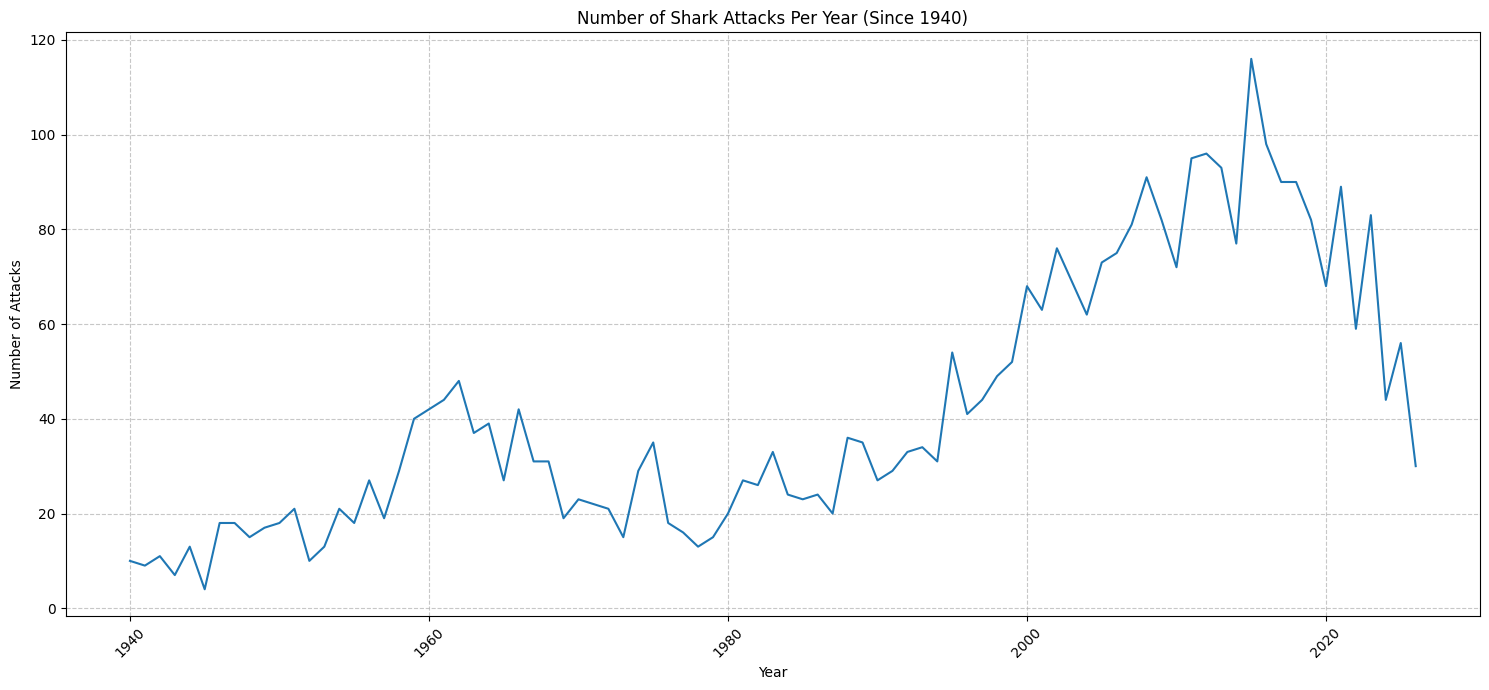

In [31]:
# To assess if attacks are increasing, decreasing, or remaining constant over time, we can visualize the number of attacks per year.

import matplotlib.pyplot as plt
import seaborn as sns

# To see how shark attacks have changed over time, we count the number of attacks for each year and then plot this data.
attacks_per_year = df_sharks_since_1940['Year_cleaned'].value_counts().sort_index().reset_index()
attacks_per_year.columns = ['Year', 'Number of Attacks']

fig = plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Number of Attacks', data=attacks_per_year)
plt.title('Number of Shark Attacks Per Year (Since 1940)')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Overall, the trend shows attacks generally increasing over time.

**Question 2 - Part 4**

Number of missing 'Age' values after initial conversion: 0

Description of 'Age_cleaned' before dropping NaNs:


,Age_cleaned
count,3947.000000
mean,28.195592
std,14.698982
min,1.000000
25%,17.000000
50%,24.000000
75%,37.000000
max,87.000000


Shape of df_sharks after dropping rows with missing ages: (3947, 27)


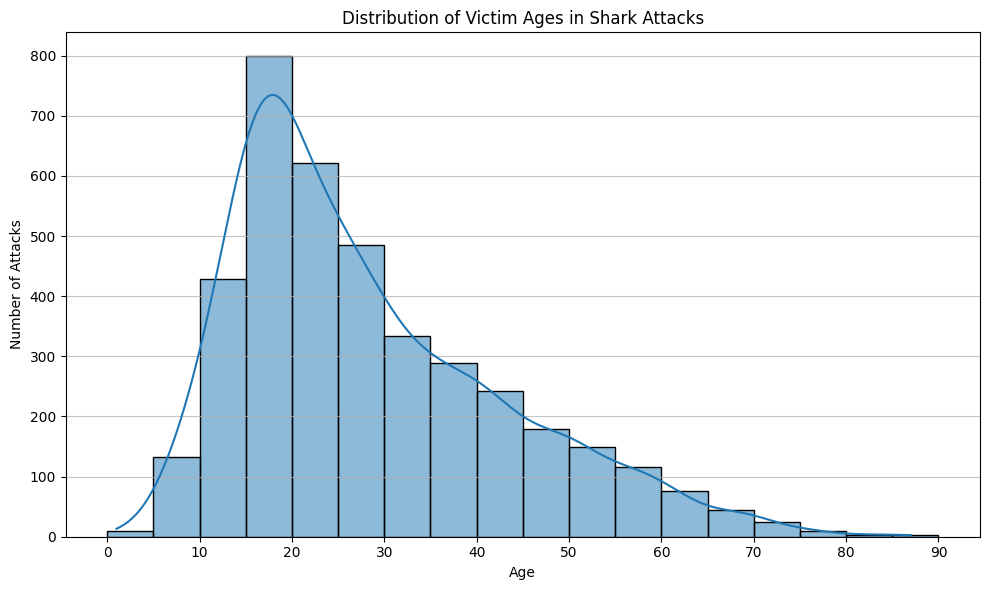

In [41]:
# I first converted the 'Age' column to numeric, setting any unreadable entries to missing (NaN) and removing rows with missing ages.
# After converting ages to whole numbers, I created a histogram to visually show how victim ages are distributed.
df_sharks['Age_cleaned'] = pd.to_numeric(df_sharks['Age'], errors='coerce')

missing_age_count = df_sharks['Age_cleaned'].isnull().sum()
print(f"Number of missing 'Age' values after initial conversion: {missing_age_count}")

print("\nDescription of 'Age_cleaned' before dropping NaNs:")
display(df_sharks['Age_cleaned'].describe())

df_sharks.dropna(subset=['Age_cleaned'], inplace=True)
print(f"Shape of df_sharks after dropping rows with missing ages: {df_sharks.shape}")

df_sharks['Age_cleaned'] = df_sharks['Age_cleaned'].astype(int)

plt.figure(figsize=(10, 6))
sns.histplot(df_sharks['Age_cleaned'], bins=range(0, int(df_sharks['Age_cleaned'].max()) + 5, 5), kde=True)
plt.title('Distribution of Victim Ages in Shark Attacks')
plt.xlabel('Age')
plt.ylabel('Number of Attacks')
plt.grid(axis='y', alpha=0.75)
plt.xticks(range(0, int(df_sharks['Age_cleaned'].max()) + 5, 10))
plt.tight_layout()
plt.show()

**Question 2 - Part 5**

In [43]:
# I cleaned the 'Sex' column to categorize victims simply as 'M' (Male), 'F' (Female), or 'Unknown' for any other entries or missing values.
df_sharks['Sex_cleaned'] = df_sharks['Sex'].str.upper().str.strip().replace({'MALE': 'M', 'FEMALE': 'F'})
df_sharks['Sex_cleaned'] = df_sharks['Sex_cleaned'].apply(lambda x: x if x in ['M', 'F'] else 'Unknown')

print("Value counts for cleaned 'Sex' variable:")
display(df_sharks['Sex_cleaned'].value_counts())

male_proportion = df_sharks['Sex_cleaned'].value_counts(normalize=True).get('M', 0)
print(f"\nProportion of male victims: {male_proportion:.2%}")

# Proportion of male victims: 84.34%

Value counts for cleaned 'Sex' variable:


,count
Sex_cleaned,
M,3329
F,584
Unknown,34



Proportion of male victims: 84.34%


**Question 2 - Part 6**

In [44]:
import numpy as np

# I cleaned the 'Type' variable by making all text uppercase and removing extra spaces
# Then, I categorized each attack as 'Unprovoked,' 'Provoked,' or 'Unknown'
df_sharks['Type_interim'] = df_sharks['Type'].astype(str).str.upper().str.strip()

# Introducing an interim 'Type' variable for cleaning
print("Value counts for interim 'Type' variable (after upper-casing and stripping, before final categorization):")
display(df_sharks['Type_interim'].value_counts())

conditions = [
    df_sharks['Type_interim'].str.contains('UNPROVOKED', na=False),
    df_sharks['Type_interim'].str.contains('PROVOKED', na=False)
]
choices = ['Unprovoked', 'Provoked']

df_sharks['Type_cleaned'] = np.select(conditions, choices, default='Unknown')

print("\nValue counts for FINAL cleaned 'Type' variable:")
display(pd.Series(df_sharks['Type_cleaned']).value_counts())

unprovoked_proportion = pd.Series(df_sharks['Type_cleaned']).value_counts(normalize=True).get('Unprovoked', 0)
print(f"\nProportion of unprovoked attacks: {unprovoked_proportion:.2%}")

# Proportion of unprovoked attacks: 83.33%

# Dropping interim column, as it's not needed anymore
df_sharks.drop(columns=['Type_interim'], inplace=True)

Value counts for interim 'Type' variable (after upper-casing and stripping, before final categorization):


,count
Type_interim,
UNPROVOKED,3289
PROVOKED,313
INVALID,229
WATERCRAFT,44
SEA DISASTER,41
QUESTIONABLE,19
NAN,10
?,1
UNDER INVESTIGATION,1



Value counts for FINAL cleaned 'Type' variable:


,count
Type_cleaned,
Unprovoked,3289
Unknown,345
Provoked,313



Proportion of unprovoked attacks: 83.33%


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID: 59055bb**

- **AI tool and model used: Claude Sonnet 5**

### *Prompts used

1. Go through this notebook and find any mistakes. Then, identify proper revisions.
2. Add the correct import statements at the top of each cell.

### *AI-proposed changes


1. Reword the Price cleaning explanation — the 181 figure is comma-formatted values (e.g. "1,990"), not raw missing values; the raw column has 0 true NaNs.
2. Stop imputing missing subject_injury to 'No'; keep missingness as its own category, and test for missingness patterns by cross-tabulating the missingness indicator against force_type directly, not the post-imputation variable.
3. Note that Year == 0 in the shark data represents undated/approximate historical records (e.g. "Ca. 214 B.C."), not a literal year.
4. Fix Age cleaning to build a separate copy of the dataframe instead of using dropna(inplace=True) on the shared df_sharks, since that silently deletes rows needed for later questions.
5. Recompute the male-victim proportion (Q2.5) on the full year-cleaned dataset, not the age-filtered subset.
6. Recompute the unprovoked-attack proportion (Q2.6) on the full year-cleaned dataset, not the age-filtered subset.
7. Restart & Run All before committing, and verify printed outputs match a clean top-to-bottom run.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Raw Price has 0 true NaNs; the 181 figure is comma-formatted values (e.g. "1,990"), verified via .isnull().sum(). |
| 2 | Accept | Crosstab of missingness vs. force_type shows Firearm is 0% missing — opposite of Phase 1's "100% missing" claim, which came from collapsing true-No and imputed-No together. |
| 3 | Accept | Year == 0 rows have Date values like "Ca. 336 B.C." — confirmed placeholders, not real years. Doesn't change the ≥1940 filter's result. |
| 4 | Accept | Execution counts are out of order (…8, 35, 10, 11, 28…); a clean rerun gives shape (7115, 24) at that cell, not the (3947, 27) shown. |
| 5 | Accept | Recomputed on full dataset (n=7,115): 80.27% male vs. Phase 1's 84.34% (computed on the 44%-smaller age-filtered subset). |
| 6 | Accept | Same fix, same dataset: 73.96% unprovoked vs. Phase 1's 83.33%. |
| 7 | Accept | Same as #4 - code run out of order |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Question 1

import pandas as pd

# --- Q1.1: Airbnb Price ---
df_airbnb = pd.read_csv('/content/A01-data-wrangling/data/airbnb_hw.csv')

# Remove commas (e.g. "1,990") before converting to numeric -- without this step,
# pd.to_numeric() would miscoerce 181 comma-formatted values to NaN. The raw
# column itself has 0 true missing values.
df_airbnb['Price'] = df_airbnb['Price'].astype(str).str.replace(',', '', regex=False)
df_airbnb['Price'] = pd.to_numeric(df_airbnb['Price'], errors='coerce')
df_airbnb['Price_nan'] = df_airbnb['Price'].isnull()

print('After cleaning:\n', df_airbnb['Price'].describe(), '\n')
df_airbnb['Price'].hist(bins=50)
print('Total missing values after cleaning:', df_airbnb['Price_nan'].sum())

# --- Q1.2: Police subject_injury ---
df_police = pd.read_csv('/content/A01-data-wrangling/data/mn_police_use_of_force.csv')

# Keep missingness as its own category rather than imputing to 'No' -- imputation
# would erase the information needed to check whether missingness is patterned.
df_police['subject_injury_cleaned'] = df_police['subject_injury'].fillna('Unknown')

proportion_missing = df_police['subject_injury'].isnull().mean()
print(f"Proportion of missing values in 'subject_injury': {proportion_missing:.4f}\n")
print('Cleaned values and counts:\n', df_police['subject_injury_cleaned'].value_counts())

# Test for missingness patterns using the missingness indicator directly,
# not the already-collapsed cleaned variable.
df_police['injury_missing'] = df_police['subject_injury'].isnull()
print('\nProportion missing by force_type:')
display(pd.crosstab(df_police['injury_missing'], df_police['force_type'], normalize='columns').round(3))

print('\nCross-tabulation of cleaned subject_injury with force_type:')
display(pd.crosstab(df_police['subject_injury_cleaned'], df_police['force_type']))

# 76.19% of subject_injury values are missing overall. This is a real concern:
# missingness is not random -- Less Lethal and Maximal Restraint Technique cases
# are ~100% missing and Bodily Force is ~75% missing, while Firearm cases are
# actually 0% missing (both are recorded as "No"), contrary to what the collapsed
# variable in Phase 1 suggested.

In [ ]:
# Question 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Q2.1 ---
df_sharks = pd.read_excel('/content/A01-data-wrangling/data/GSAF5.xls')

# --- Q2.2 ---
print(f"Shape before dropping empty columns: {df_sharks.shape}")
df_sharks = df_sharks.dropna(axis=1, how='all')
print(f"Shape after dropping empty columns: {df_sharks.shape}")

# --- Q2.3: Year ---
df_sharks['Year_cleaned'] = pd.to_numeric(df_sharks['Year'], errors='coerce')
df_sharks.dropna(subset=['Year_cleaned'], inplace=True)
df_sharks['Year_cleaned'] = df_sharks['Year_cleaned'].astype(int)

min_year, max_year = df_sharks['Year_cleaned'].min(), df_sharks['Year_cleaned'].max()
print(f"Range of cleaned 'Year' values: {min_year} to {max_year}")
# Year == 0 represents undated/approximate historical records (e.g. "Ca. 214 B.C.",
# "Prior to 1988"), not a literal year; these drop out once filtered to >= 1940.

df_sharks_since_1940 = df_sharks[df_sharks['Year_cleaned'] >= 1940].copy()
print(f"Shape since 1940: {df_sharks_since_1940.shape}")

attacks_per_year = df_sharks_since_1940['Year_cleaned'].value_counts().sort_index().reset_index()
attacks_per_year.columns = ['Year', 'Number of Attacks']

fig = plt.figure(figsize=(15, 7))
sns.lineplot(x='Year', y='Number of Attacks', data=attacks_per_year)
plt.title('Number of Shark Attacks Per Year (Since 1940)')
plt.xlabel('Year'); plt.ylabel('Number of Attacks')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Attacks trend upward since 1940.

# --- Q2.4: Age (uses its own copy so other questions aren't affected) ---
df_sharks['Age_cleaned'] = pd.to_numeric(df_sharks['Age'], errors='coerce')
missing_age_count = df_sharks['Age_cleaned'].isnull().sum()
print(f"Missing/unparseable 'Age' values: {missing_age_count} of {len(df_sharks)} "
      f"({missing_age_count/len(df_sharks):.1%}) -- a large share of the data; "
      f"the histogram below reflects only records with a usable age.")

df_age = df_sharks.dropna(subset=['Age_cleaned']).copy()
df_age['Age_cleaned'] = df_age['Age_cleaned'].astype(int)

plt.figure(figsize=(10, 6))
sns.histplot(df_age['Age_cleaned'], bins=range(0, int(df_age['Age_cleaned'].max()) + 5, 5), kde=True)
plt.title('Distribution of Victim Ages in Shark Attacks')
plt.xlabel('Age'); plt.ylabel('Number of Attacks')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# --- Q2.5: Sex (computed on the full df_sharks, not the age-filtered subset) ---
df_sharks['Sex_cleaned'] = df_sharks['Sex'].astype(str).str.upper().str.strip().replace({'MALE': 'M', 'FEMALE': 'F'})
df_sharks['Sex_cleaned'] = df_sharks['Sex_cleaned'].apply(lambda x: x if x in ['M', 'F'] else 'Unknown')
print(df_sharks['Sex_cleaned'].value_counts())
male_proportion = df_sharks['Sex_cleaned'].value_counts(normalize=True).get('M', 0)
print(f"Proportion of male victims: {male_proportion:.2%}")

# --- Q2.6: Type (computed on the full df_sharks, not the age-filtered subset) ---
df_sharks['Type_interim'] = df_sharks['Type'].astype(str).str.upper().str.strip()
conditions = [
    df_sharks['Type_interim'].str.contains('UNPROVOKED', na=False),
    df_sharks['Type_interim'].str.contains('PROVOKED', na=False)
]
choices = ['Unprovoked', 'Provoked']
df_sharks['Type_cleaned'] = np.select(conditions, choices, default='Unknown')
print(df_sharks['Type_cleaned'].value_counts())
unprovoked_proportion = pd.Series(df_sharks['Type_cleaned']).value_counts(normalize=True).get('Unprovoked', 0)
print(f"Proportion of unprovoked attacks: {unprovoked_proportion:.2%}")

df_sharks.drop(columns=['Type_interim'], inplace=True)

### *Reflection on AI assistance

In your own words without generative AI

The AI assistance helped make the data cleaning processes a lot clearer. A significant improvement came with the 'Price' variable; what initially looked like 181 missing values were actually just numbers with commas (like '1,990'). AI identified that after removing these commas, there were actually no true missing price values at all.

For the 'subject_injury' variable, instead filling in missing injury reports with 'No,' AI suggested that they're treated as their own 'Unknown' category. This change was crucial, as it revealed that missing data wasn't random.

It also pinpointed how some of the earlier steps were unintentionally affecting later calculations. Specifically, 'inplace=True' and filtering for 'Age' were changing the dataset for subsequent questions on 'Sex' and 'Type.' By restructuring these steps to use separate copies of the data where needed, I was able to ensure that the proportions for male victims and unprovoked attacks were calculated based on the correct, complete datasets.

On the downside, AI's suggestions were more about optimizing existing logic rather than catching fundamental errors. I verified all changes by running the entire notebook again to confirm everything was consistent. My main remaining concern is the high proportion of missing 'subject_injury' values (76.19%), especially since this missingness isn't random. This could still impact how reliably we can draw conclusions from that specific variable.